# Reflection Spectra over Frequencies for Radar Design

In this example, we reproduce the result of Fig. 7 in the work [1].

[1] Eric Michielssen, Jean-Michel Sajer, S. Ranjithan, and Raj Mittra. [Design of lightweight, broad-band microwave absorbers using genetic algorithms](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=238519&casa_token=cAzTLiuvjPcAAAAA:iW8Ema9V9aE9lUAGOst4mGaeFeh45hGqOAJY1-ieAXdYcAqUmrNo1d3PpHUrecssvVvZzWK6rg&tag=1). *IEEE Transactions on Microwave Theory and Techniques*, vol. 41, no. 6, pp. 1024–1031, 1993.

First, the required packages are imported.

In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber
import os
import re


Now, the appropriate functions are defined (12_1, 12_4, 12_6, 12_7, 12_8, parsecomplexsafe, getfreq)

NOTE: 12_4, 12_7 and 12_8 are not currently working

In [155]:
# Parse complex safe
def parse_complex_safe(s):
    """
    Parse a string from a PDF table into a complex number.
    Handles weird cases like '1.6503+', '2.34- 0.56i', etc.
    """
    if s is None:
        return complex(0, 0)
    
    s = s.strip()  # remove leading/trailing whitespace
    s = s.replace(" ", "")  # remove internal spaces
    s = s.replace('\n', '') # remove internal line breaks
    s = s.replace("i", "j")  # Python uses j for imaginary unit
    s = s.replace('–', '-') # adjusts dash type (em to en)

    # Fix cases where string ends with + or - (incomplete imaginary part)
    if re.match(r"^[+-]?[\d.]+[+-]$", s):
        s += "0j"  # add 0 as imaginary part
    
    # Fix cases where string is just a real number with trailing j
    if re.match(r"^[+-]?[\d.]+$", s):
        s += "+0j"

    try:
        c = complex(s)
    except ValueError:
        # fallback: treat as 0+0j
        c = complex(0, 0)
    return c

In [156]:
# Get frequency range
def get_frequency_range_from_pdf(material, pdf_path):
    '''
    Extracts the frequency range (min, max) for a given material
    from the PDF text.
    '''
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            for line in text.split("\n"):
                if material.lower() in line.lower():
                    # Look for (X–Y GHz) after the material name
                    match = re.search(r"\((\d*\.?\d+)–(\d*\.?\d+)\s*GHz\)", line)
                    if match:
                        f_min = float(match.group(1))
                        f_max = float(match.group(2))
                        return f_min, f_max
    return None, None

In [157]:
# 12_1
def getEpAndMu_12_1(user_f_min, user_f_max, material):
    #base_dir = os.path.dirname(__file__)  # folder where script is
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_1.pdf")

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)
    
    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    rows = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]


    # Apply to the selected row
    real_floats = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe).apply(lambda x: x.real)
    imag_floats = df_selected.iloc[sample_idx].apply(parse_complex_safe).apply(lambda x: x.imag)

    complex_floats = real_floats + imag_floats * complex(0, 1)
    complex_floats.head()

    B = complex_floats.iloc[0]
    C = complex_floats.iloc[1]
    D = complex_floats.iloc[2]
    G = complex_floats.iloc[3]
    H = complex_floats.iloc[4]
    I = complex_floats.iloc[5]
    J = complex_floats.iloc[6]
    
    num_points = 1000  # Number of frequency points
   
    frequencies = np.linspace(user_f_min, user_f_max, num_points)
    epsilon_f = B + 2 * C * (frequencies ** D) + G * (1 - J * (frequencies - H)**2 - 1j * 2 * I * frequencies)**(-1)


    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(f_min, f_max)
    plt.ylim(1e-4, 1e4)
    plt.show()

In [158]:
# 12_4
def getEpAndMu_12_4(user_f_min, user_f_max, material):
    return

In [159]:
# 12_6
def getEpAndMu_12_6(user_f_min, user_f_max, material):
    #base_dir = os.path.dirname(__file__)  # folder where script is
    base_dir = os.getcwd()

    pdf_path = os.path.join(base_dir, "12_6.pdf")

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)

    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(material, na=False)].index[0]

    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)
    # Convert single string into complex float
    df_selected = df[["B", "C", "D", "E", "F", "G", "H"]]

    values = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe)

    B = complex(values.iloc[0])
    C = complex(values.iloc[1])
    D = complex(values.iloc[2])
    E = complex(values.iloc[3])
    F = complex(values.iloc[4])
    G = complex(values.iloc[5])
    H = complex(values.iloc[6])

    #define frequency range

    num_points = 1000  # Number of frequency points
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = (B + np.real(C) * (frequencies ** D) + np.imag(C) * (frequencies ** E) + F * (1 - (frequencies / G) ** 2 - 1j * 2 * frequencies / H) ** (-1))

    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(user_f_min, user_f_max)
    plt.ylim(1e-4, 1e4)
    plt.show()

In [160]:
# 12_7
def getEpAndMu_12_7(user_f_min, user_f_max, material):
    base_dir = os.getcwd()
    pdf_path = os.path.join(base_dir, "12_7.pdf")

    # Get frequency range automatically
    f_min, f_max = get_frequency_range_from_pdf(material, pdf_path)
    if f_min is None or f_max is None:
        # raise ValueError(f"Could not find frequency range for {material}")
        f_min = 0.2
        f_max = 250
        print('Low and high frequncies not found, defaulting to 0.2-250GHz')
    user_f_min = float(user_f_min)
    user_f_max = float(user_f_max)

    if user_f_min < f_min or user_f_max > f_max:
        print(f"\n\nWARNING: Frequency range {f_min}–{f_max} GHz is defined for {material}. All data outside of this range will be extrapolated.")
    rows = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    sample_name = material

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(sample_name, na=False)].index[0]

    print( (sample_name + " sample row index:"), sample_idx)

    # Row 2 (index=2) has B, C, D, G, H, I, J
    df.columns = df.iloc[2]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","G","H","I","J"]] will work
    df_selected = df[["B", "C", "D", "G", "H", "I", "J"]]

    # Acquire real and imag components
    real = df_selected.iloc[sample_idx - 1]
    imag = df_selected.iloc[sample_idx]

    # Combine into complex numbers
    combined = real.astype(str) + imag.astype(str)

    # Apply to the selected row
    real_floats = df_selected.iloc[sample_idx - 1].apply(parse_complex_safe).apply(lambda x: x.real)
    imag_floats = df_selected.iloc[sample_idx].apply(parse_complex_safe).apply(lambda x: x.imag)

    complex_floats = real_floats + imag_floats * complex(0, 1)
    complex_floats.head()

    B = complex_floats.iloc[0]
    C = complex_floats.iloc[1]
    D = complex_floats.iloc[2]
    G = complex_floats.iloc[3]
    H = complex_floats.iloc[4]
    I = complex_floats.iloc[5]
    J = complex_floats.iloc[6]

    num_points = 1000
    frequencies = np.linspace(user_f_min, user_f_max, num_points)

    epsilon_f = B + 2 * C * (frequencies ** D) + G * (1 - J * (frequencies - H)**2 - 1j * 2 * I * frequencies)**(-1)

    #permeability (mu = 1 for non-farreous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(1e-1, 1e3)
    plt.ylim(1e-4, 10)
    plt.show()
    

In [161]:
# 12_8
def getEpAndMu_12_8(user_f_min, user_f_max, material):
    base_dir = os.getcwd()
    pdf_path = os.path.join(base_dir, "12_8.pdf")

    rows = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table)

    df = pd.DataFrame(rows)

    #Sample name is "7058 Epoxy with about 40%/volume 52-μm silica hollow spheres, 3–5μμm walls (2–18 GHz)"
    sample_name = material

    # find the row index where this sample name appears
    sample_idx = df[df.iloc[:,0].str.contains(sample_name, na=False)].index[0]

    print( (sample_name + " sample row index:"), sample_idx)

    # Row 2 (index=2) has B, C, D, E, F, G, H, I, J
    df.columns = ["B", "C", "D", "E", "F", "G", "H", "I", "J"]

    df = df.drop([0, 1]).reset_index(drop=True)

    # Now df[["B","C","D","E","F","G","H","I","J"]] will work
    df_selected = df[["B","C","D","E","F","G","H","I","J"]]

    # Acquire real and imag components - for this section they are combined
    values = df_selected.iloc[sample_idx - 1]

    # remove /n and change dashes
    new_values = values.str.replace('\n', '', regex=False)
    final_values = new_values.str.replace('–', '-', regex=False)

    
    # Convert single string into complex float using robust parser
    B = parse_complex_safe(final_values.iloc[0])
    C = parse_complex_safe(final_values.iloc[1])
    D = parse_complex_safe(final_values.iloc[2])
    E = parse_complex_safe(final_values.iloc[3])
    F = parse_complex_safe(final_values.iloc[4])
    G = parse_complex_safe(final_values.iloc[5])
    H = parse_complex_safe(final_values.iloc[6])
    I = parse_complex_safe(final_values.iloc[7])
    J = parse_complex_safe(final_values.iloc[8])

    #define frequency range
    f_min = 2  # GHz
    f_max = 18  # GHz
    num_points = 100 - 1  # Number of frequency points
    frequencies = np.linspace(f_min, f_max, num_points)

    epsilon_f = (B + (2*C*(frequencies**D)) + (E*(frequencies**frequencies)) + (G*(1 - (J *(frequencies - H)**2) - (1j*2*I*frequencies))**-1))

    #permeability (mu = 1 for non-ferrous)
    mu_f = np.ones(frequencies.shape)

    # loglog plot
    plt.figure()
    plt.loglog(frequencies, np.real(epsilon_f), 'b-', linewidth=2, label='Re($\epsilon$)')
    plt.loglog(frequencies, np.imag(epsilon_f), 'r--', linewidth=2, label='Im($\epsilon$)')
    plt.xlabel('Frequency [GHz]', fontsize=12)
    plt.ylabel('Epsilon', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, which="both", ls="--")
    plt.title('Real and Imaginary Permittivity vs. Frequency', fontsize=14)
    plt.xlim(0, 20)
    plt.ylim(1e-1, 1e6)
    plt.show()


Now, the user is asked for the material, low frequency range, and high frequency range

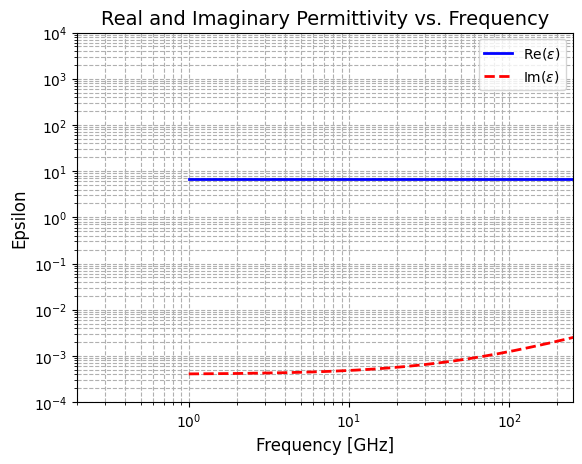

Primary function successful.


In [162]:
material = input('Enter a material: ')
user_f_min = input('Enter a minimum frequency')
user_f_max = input('Enter a maximum frequency')

# Try each function, if no such material is found the user is told.

try:
    getEpAndMu_12_1(user_f_min, user_f_max, material)
except:
    try:
        getEpAndMu_12_6(user_f_min, user_f_max, material)
    except:
        try:
            getEpAndMu_12_7(user_f_min, user_f_max, material)
        except:
            try:
                getEpAndMu_12_8(user_f_min, user_f_max, material)
            except:
                print('Material not found')
     
else:
    print("Primary function successful.")